In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import scanpy as sc
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from tqdm.notebook import tqdm

In [2]:
adata = sc.read_h5ad('../data/simulation/TM_subset_cnt.h5ad')
celltype_cnts = adata.obs['cell_type'].value_counts()
celltype_cnts = celltype_cnts[celltype_cnts >= 30]

In [3]:
n_bins = 5

In [4]:
files = Path('../data/simulation/causal_simulation').rglob('tc__*.csv')
files = [str(file) for file in files]
ground_truth = {}
for file in tqdm(files, total=len(files)):
    setting = Path(file).parent.name
    runid = Path(file).stem.split('__')[1]
    ground_truth[f'{setting}__run-{runid}'] = pd.read_csv(file, header=None, index_col=None, sep='\t').iloc[0, 0]

  0%|          | 0/17000 [00:00<?, ?it/s]

In [5]:
# load icepop res
res_df = []

for mc_size in [30, 50, 75]:
    base_dir = Path(f"../results/icepop_casual_mc-{mc_size}")
    files = list(base_dir.rglob("celltype__trait*.csv"))
    dfs = []
    for file in tqdm(files, desc=f"mc-{mc_size}", total=len(files)):
        file = Path(file)
        setting = file.parent.name
        runid = file.stem.split("__trait-gwasz__")[1].split(".")[0]
        params = {
            k: float(v)
            for k, v in (p.split("-") for p in setting.split("__"))
        }
        df = pd.read_csv(
            file,
            usecols=["cell_type", "q"],
        )
        df["target"] = ground_truth[f"{setting}__run-{runid}"]
        df["run_idx"] = runid
        df["method"] = f"mc-{mc_size}"
        for k, v in params.items():
            df[k] = v
        dfs.append(df)
    res_df.append(pd.concat(dfs, ignore_index=True))

# final combined result
res_df = pd.concat(res_df, ignore_index=True)
res_df = res_df[res_df['target'] == res_df['cell_type']]
res_df['discovery'] = res_df['q'] <= 0.1

# divide into cell count bins
bins = pd.qcut(celltype_cnts, q=n_bins, labels=[f"bin_{i+1}" for i in range(n_bins)])
res_df['cell_type_cnts'] = list(celltype_cnts.loc[res_df['cell_type']])
res_df['bins'] = list(bins.loc[res_df['cell_type']])

mc-30:   0%|          | 0/17000 [00:00<?, ?it/s]

mc-50:   0%|          | 0/17000 [00:00<?, ?it/s]

mc-75:   0%|          | 0/17000 [00:00<?, ?it/s]

In [6]:
NOISE_SD_FIXED = 1.0
BETA_FIXED = 1.0
FRAC_SIGNAL_FIXED = 0.01
SAMPLE_RATE_FIXED = 1.0

# experiment A: vary signal strength
FRAC_SIGNAL_LIST = [0.001, 0.005, 0.01, 0.05, 0.1]

# experiment B: vary noise_sd
NOISE_SD_LIST = [0.1, 0.5, 1.0, 2.0, 5.0]

# experiment C: vary beta
BETA_LIST = [0.1, 0.5, 1.0, 2.0, 5.0]

# experiment D: vary cell sampling rate
SAMPLE_RATE_LIST = [0.2, 0.4, 0.6, 0.8, 1.0]

# experiment A: vary signal strength

In [7]:
def prepare_plot(res_df, vlabel='sf', bins=None):
    if vlabel == 'sf':
        a_df = res_df[
            (res_df['sf'].isin(FRAC_SIGNAL_LIST)) &
            (res_df['ns'] == NOISE_SD_FIXED) &
            (res_df['b'] == BETA_FIXED) &
            (res_df['sr'] == SAMPLE_RATE_FIXED)
        ]
    elif vlabel == 'ns':
        a_df = res_df[
            (res_df['sf'] == FRAC_SIGNAL_FIXED) &
            (res_df['ns'].isin(NOISE_SD_LIST)) &
            (res_df['b'] == BETA_FIXED) &
            (res_df['sr'] == SAMPLE_RATE_FIXED)
        ]
    elif vlabel == 'b':
        a_df = res_df[
            (res_df['sf'] == FRAC_SIGNAL_FIXED) &
            (res_df['ns'] == NOISE_SD_FIXED) &
            (res_df['b'].isin(BETA_LIST)) &
            (res_df['sr'] == SAMPLE_RATE_FIXED)
        ]
    elif vlabel == 'sr':
        a_df = res_df[
            (res_df['sf'] == FRAC_SIGNAL_FIXED) &
            (res_df['ns'] == NOISE_SD_FIXED) &
            (res_df['b'] == BETA_FIXED) &
            (res_df['sr'].isin(SAMPLE_RATE_LIST))
        ]
    if bins is not None:
        a_df = a_df[a_df["bins"] == bins]

    # -----------------------
    # compute power per (vlabel, seed, method)
    # -----------------------
    df = (
        a_df
        .groupby([vlabel, "seed", "method"])["discovery"]
        .mean()
        .rename("power")
        .reset_index()
    )

    return df

def overall_perf(
    res_df, vlabel, outfile=None,
    xlabel="Signal fraction",
    ylabel='Power', show_legend=False
):
    df = prepare_plot(res_df, vlabel=vlabel)
    
    plt.figure(figsize=(5,3))
    
    # Bar = mean across seeds
    sns.barplot(
        data=df,
        x=vlabel,
        y="power",
        hue="method",
        errorbar=None,      # important: avoid double-encoding uncertainty
    )
    
    # Dots = individual seeds
    sns.stripplot(
        data=df,
        x=vlabel,
        y="power",
        hue="method",
        dodge=True,
        jitter=0.15,
        palette=["black", "black", "black"],
        size=4,
        alpha=0.8,
    )
    
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(-0.03, 1.03)
    plt.title("")

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles[:df["method"].nunique()],
            labels[:df["method"].nunique()],
            frameon=False,
            fontsize=11,
        )
    else:
        ax.legend().remove()

    plt.tight_layout()

    if outfile:
        plt.savefig(outfile)
    else:
        plt.show()

def split_by_ct_perf(
    res_df, vlabel, outfile,
    xlabel="Signal fraction",
    ylabel='Power', xticks_order=None
):
    fig, axs = plt.subplots(
        ncols=5, nrows=1,
        sharey=True,
        sharex=True,
        figsize=(15, 3.5),
    )

    for i in range(5):
        idx = i + 1
        cur_bin = f"bin_{idx}"
    
        df = prepare_plot(res_df, vlabel=vlabel, bins=cur_bin)

        if xticks_order is not None:
            sns.barplot(
                data=df,
                x=vlabel,
                y="power",
                hue="method",
                errorbar=None,
                ax=axs[i],
                order=xticks_order
            )
        else:
            sns.barplot(
                data=df,
                x=vlabel,
                y="power",
                hue="method",
                errorbar=None,
                ax=axs[i],
            )            
        
        sns.stripplot(
            data=df,
            x=vlabel,
            y="power",
            hue="method",
            dodge=True,
            jitter=0.15,
            palette=["black", "black", "black"],
            size=3.5,
            clip_on=False,
            ax=axs[i],
            alpha=0.8,
        )
    
        min_cnt = celltype_cnts[bins[bins == cur_bin].index].min()
        max_cnt = celltype_cnts[bins[bins == cur_bin].index].max()
    
        axs[i].set_xlabel("")
        if i == 0:
            axs[i].set_ylabel(ylabel, fontsize=14)
        else:
            axs[i].set_ylabel("")
    
        axs[i].set_ylim(-0.03, 1.03)
    
        title_bin = cur_bin.replace("_", " ")
        axs[i].set_title(
            f"Cell type {title_bin}: {min_cnt:,}-{max_cnt:,}"
        )

        axs[i].tick_params(axis="x", labelsize=12)
        axs[i].tick_params(axis="y", labelsize=12)
    
        axs[i].legend().remove()
        axs[i].spines["top"].set_visible(False)
        axs[i].spines["right"].set_visible(False)
    
    fig.subplots_adjust(
        left=0.04,    # reduce left margin
        right=0.995,  # reduce right margin
        bottom=0.18,  # space for xlabel
        top=0.88,     # space for titles
        wspace=0.15   # less space between panels
    )
    fig.supxlabel(xlabel, fontsize=14)
    
    plt.savefig(outfile, bbox_inches="tight")

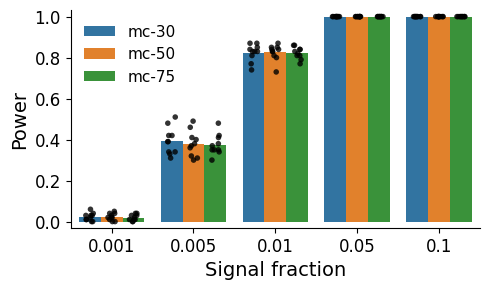

In [8]:
# check legend and don't output figure
vlabel = 'sf'
overall_perf(
    res_df, vlabel,
    xlabel="Signal fraction",
    ylabel='Power', show_legend=True
)

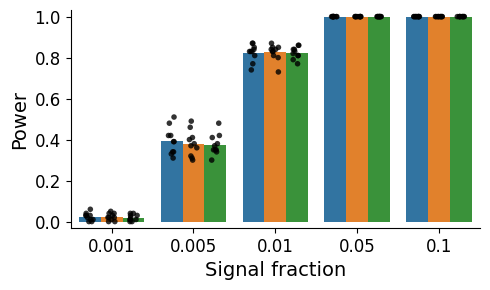

In [9]:
vlabel = 'sf'
overall_perf(
    res_df, vlabel,
    "../paper/supp/causal_sf_mc.pdf",
    xlabel="Signal fraction",
    ylabel='Power'
)

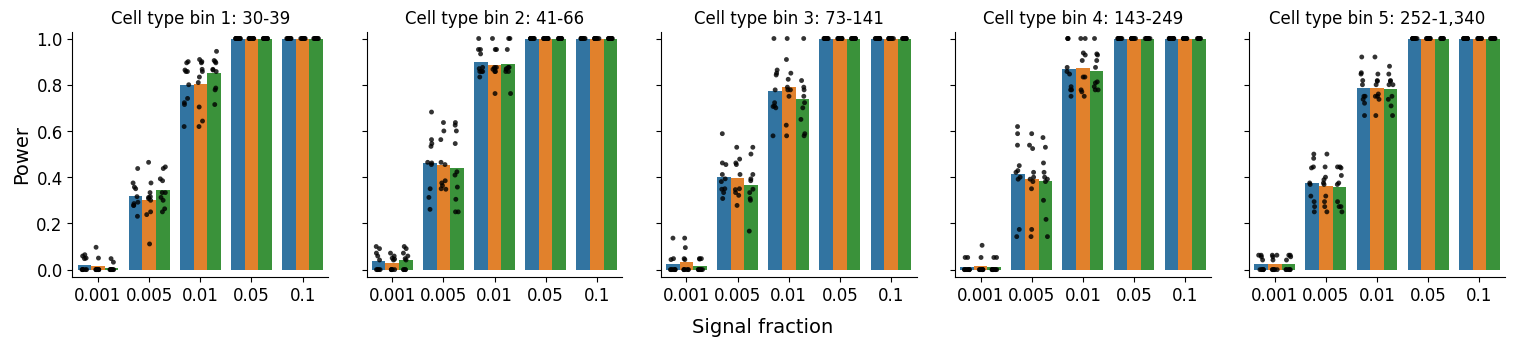

In [10]:
split_by_ct_perf(
    res_df, vlabel,
    "../paper/supp/causal_sf_ctsize_mc.pdf",
    xlabel="Signal fraction",
    ylabel='Power'
)

# experiment B: vary noise_sd

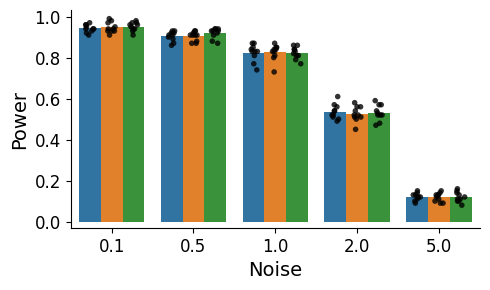

In [11]:
vlabel = 'ns'
overall_perf(
    res_df, vlabel, "../paper/supp/causal_ns_mc.pdf",
    xlabel="Noise",
    ylabel='Power',
)

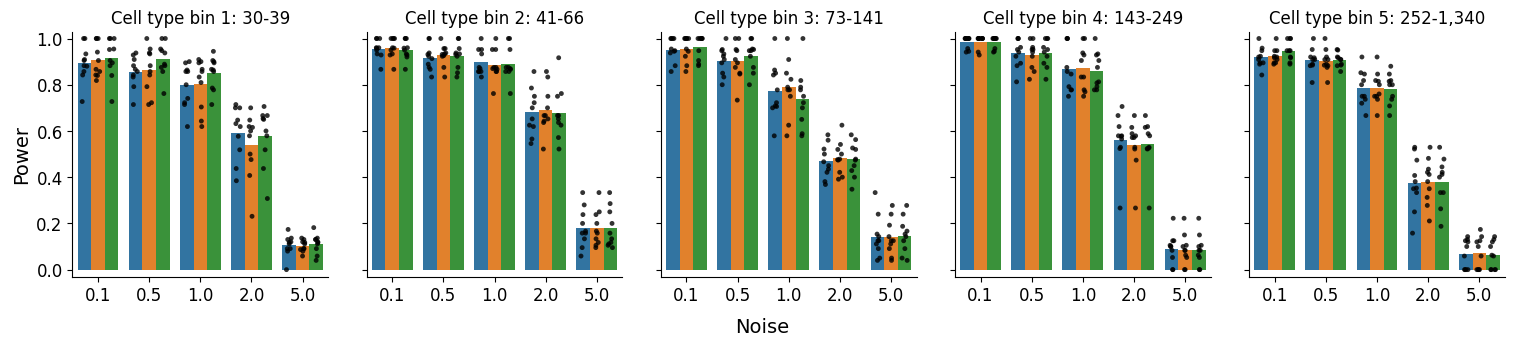

In [12]:
split_by_ct_perf(
    res_df, vlabel,
    "../paper/supp/causal_ns_ctsize_mc.pdf",
    xlabel="Noise",
    ylabel='Power'
)

# experiment C: vary beta

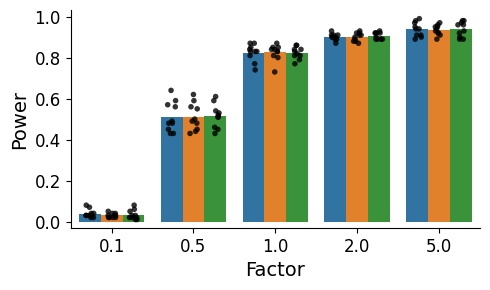

In [13]:
vlabel = 'b'
overall_perf(
    res_df, vlabel, "../paper/supp/causal_factor_mc.pdf",
    xlabel="Factor",
    ylabel='Power',
)

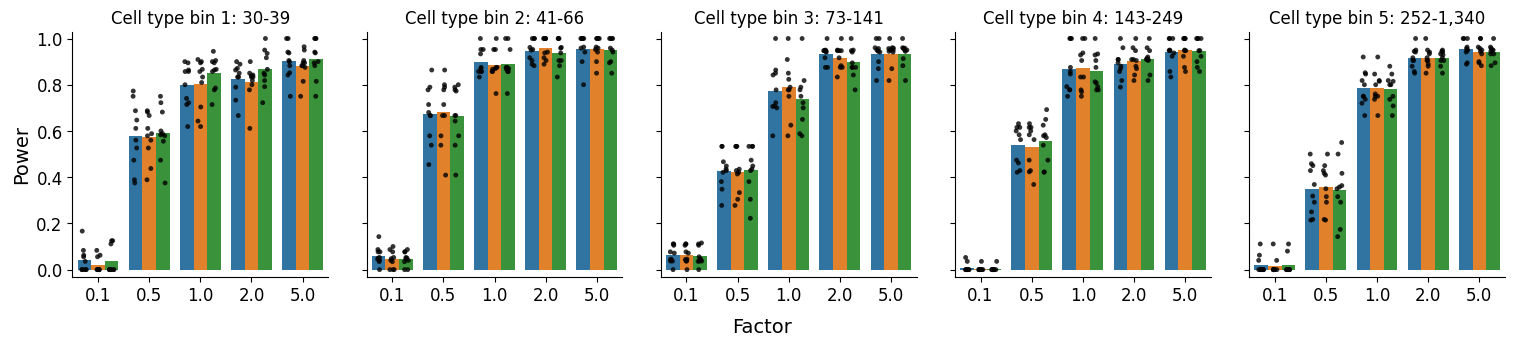

In [14]:
split_by_ct_perf(
    res_df, vlabel,
    "../paper/supp/causal_factor_ctsize_mc.pdf",
    xlabel="Factor",
    ylabel='Power'
)

# experiment D: vary sample rate

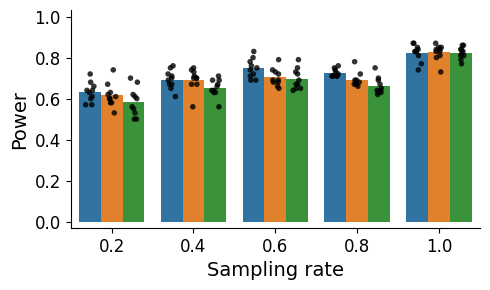

In [15]:
vlabel = 'sr'
overall_perf(
    res_df, vlabel, "../paper/supp/causal_sr_mc.pdf",
    xlabel="Sampling rate",
    ylabel='Power',
)

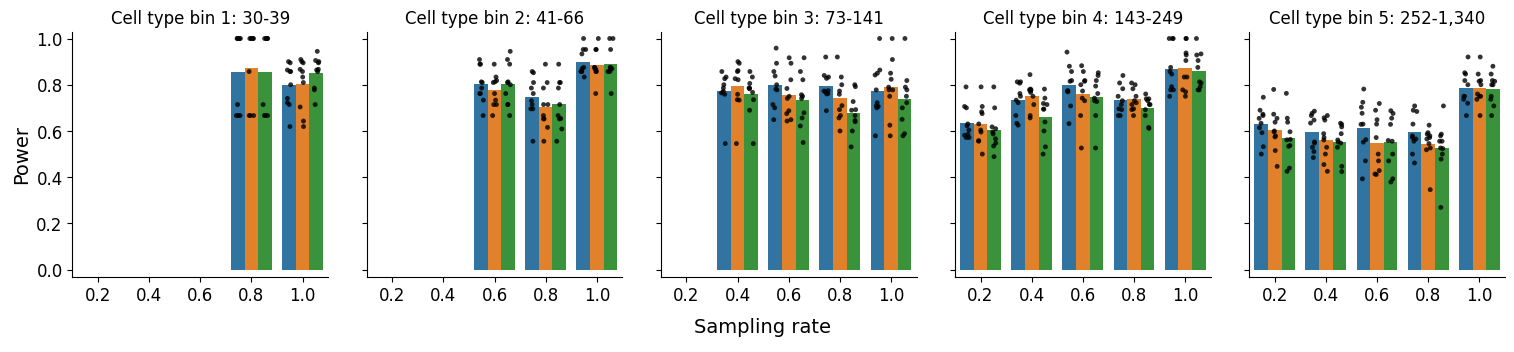

In [16]:
split_by_ct_perf(
    res_df, vlabel,
    "../paper/supp/causal_sr_ctsize_mc.pdf",
    xlabel="Sampling rate",
    ylabel='Power',
    xticks_order=[0.2, 0.4, 0.6, 0.8, 1.0]
)